# Practical 1: Introduction to Python and Jupyter

In this small tutorial, we will download a real dataset from **Natural Earth** (free, public domain geodata) and display it in three different ways.

*`test`*


## Working with Jupyter Notebooks

Jupyter Notebooks are documents that can be used and run inside the JupyterLab programming environment, containing computer code and rich text elements (such as text, figures, tables, and links).


### A couple of hints

- Run a selected cell with **Shift + Enter** (or the Run/Play button).
- Use **Markdown** cells for text and **Code** cells for Python code.

---

## 0. Install dependencies

Run the next cell once to install the required libraries. If the libraries are already installed, rerunning it is safe.



In [ ]:
# Install required libraries (safe to re-run)
%pip install geopandas folium matplotlib --quiet

## 1. Download the dataset

We use the **Natural Earth** 1:10m populated places dataset.
It contains cities and towns worldwide as points.

> **Source:** https://www.naturalearthdata.com/  
> License: Public Domain — free to use for any purpose.

In [ ]:
import geopandas as gpd

# Natural Earth 1:10m populated places (hosted on GitHub by the Natural Earth project)
URL = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places_simple.zip"

# GeoPandas can read shapefiles directly from a URL (including inside a ZIP)
world_cities = gpd.read_file(URL)

print(f"Downloaded {len(world_cities)} cities worldwide.")

We use the **Natural Earth** 1:10m country boundaries dataset.
It contains country outlines worldwide as polygons.

> **Source:** https://www.naturalearthdata.com/  
> License: Public Domain — free to use for any purpose.

In [ ]:

# Natural Earth 1:10m country boundaries (for border outlines)
COUNTRIES_URL = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
countries = gpd.read_file(COUNTRIES_URL)
print(f"Downloaded {len(countries)} country polygons.")


Downloaded 258 country polygons.


## 2. Filter data for countries of interest

We now subset the global city dataset into country-specific GeoDataFrames.
- `finland` for the static Matplotlib example
- `austria` for the interactive Folium example

Then we select a few useful attribute columns for quick inspection.

In [ ]:
# Filter rows where the country code is Finland
finland = world_cities[world_cities["adm0_a3"] == "FIN"].copy()

# Filter rows where the country code is Austria
austria = world_cities[world_cities["adm0_a3"] == "AUT"].copy()

# Select only the most useful columns for display
cols = ["name", "pop_max", "adm1name", "latitude", "longitude"]

# .reset_index() gives a clean 0, 1, 2 ... index
finland[cols].reset_index(drop=True)

,name,pop_max,adm1name,latitude,longitude
0,Hämeenlinna,47261,Tavastia Proper,60.996996,24.472000
1,Kouvola,31133,Southern Finland,60.876000,26.709004
2,Mikkeli,46550,Southern Savonia,61.689996,27.285004
3,Savonlinna,27353,Southern Savonia,61.866623,28.883343
4,Pori,76772,Satakunta,61.478895,21.774939
5,Sodankylä,8942,Lapland,67.417059,26.600020
6,Jyväskylä,98136,Central Finland,62.260346,25.749994
7,Kuopio,91900,Eastern Finland,62.894286,27.694940
8,Lappeenranta,59276,South Karelia,61.067059,28.183334
9,Porvoo,12242,Eastern Uusimaa,60.400356,25.666020


## 3. Static map with Matplotlib + GeoPandas

In this section, we draw Finland's country border and overlay populated places.
City names are added as annotations to make the map easier to read.

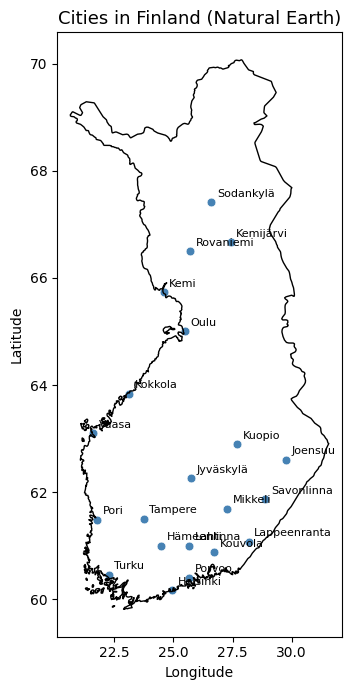

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 7))

# Draw Finland's border
finland_border = countries[countries["ADM0_A3"] == "FIN"]
finland_border.boundary.plot(ax=ax, color="black", linewidth=1)

finland.plot(
    ax=ax,
    color="steelblue",
    markersize=40,
    edgecolor="white",
    linewidth=0.5,
)

# Label each city
for _, row in finland.iterrows():
    ax.annotate(
        row["name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Cities in Finland (Natural Earth)", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 4. Interactive map with Folium

Finally, we create a web map centered on Austria.
We add the Austria border as a GeoJSON layer and draw one circle marker per Austrian city with a popup and tooltip.

In [ ]:
import folium

# Create a map centred on Austria using CartoDB Positron as the only basemap
m = folium.Map(
    location=[47.5, 14.5],
    zoom_start=7,
    tiles="CartoDB positron",
)

# Add Austria border as a GeoJSON layer
austria_border = countries[countries["ADM0_A3"] == "AUT"]
folium.GeoJson(
    data=austria_border.__geo_interface__,
    style_function=lambda _: {
        "fillColor": "lightyellow",
        "color": "black",
        "weight": 2,
        "fillOpacity": 0.25,
    },
    name="Austria border",
).add_to(m)

# Add one CircleMarker per Austrian city
for _, row in austria.iterrows():
    is_capital = row["name"] == "Vienna"
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6 if is_capital else 4,
        color="steelblue",
        fill=True,
        fill_opacity=0.8,
        tooltip=row["name"],
    ).add_to(m)

# Fit view to Austria boundary
bounds = austria_border.total_bounds  # minx, miny, maxx, maxy
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

m